In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
df = pd.read_csv("/content/nassau_candy_cleaned.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (10194, 32)


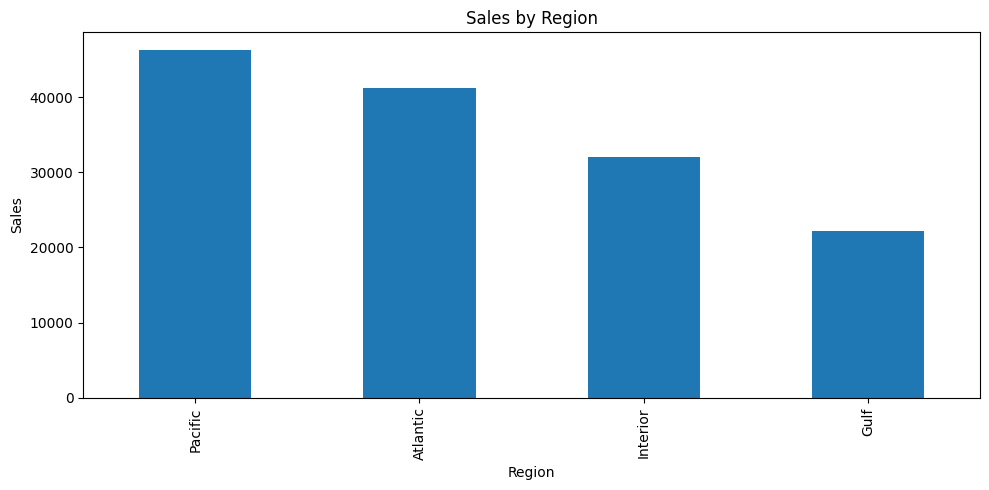

In [2]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales.plot(kind="bar", figsize=(10,5))

plt.title("Sales by Region")
plt.ylabel("Sales")
plt.xlabel("Region")

plt.tight_layout()
plt.show()

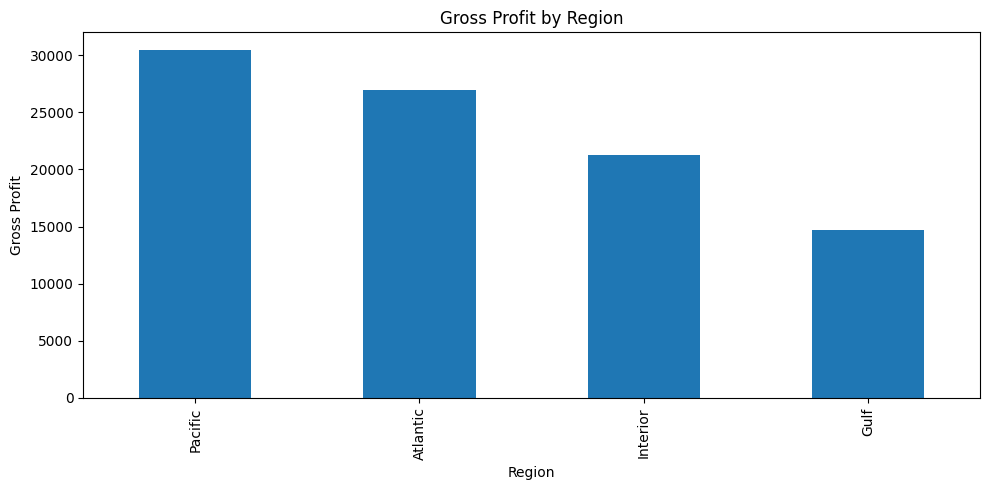

In [3]:
region_profit = (
    df.groupby("Region")["Gross Profit"]
    .sum()
    .sort_values(ascending=False)
)

region_profit.plot(kind="bar", figsize=(10,5))

plt.title("Gross Profit by Region")
plt.ylabel("Gross Profit")
plt.xlabel("Region")

plt.tight_layout()
plt.show()

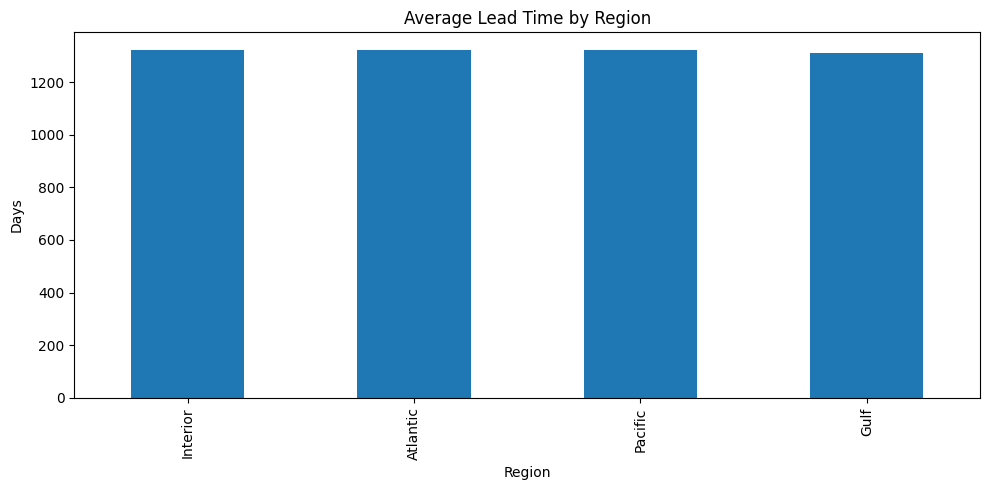

In [5]:
region_lead = (
    df.groupby("Region")["Lead Time Days"]
    .mean()
    .sort_values(ascending=False)
)

region_lead.plot(kind="bar", figsize=(10,5))

plt.title("Average Lead Time by Region")
plt.ylabel("Days")
plt.xlabel("Region")

plt.tight_layout()
plt.show()

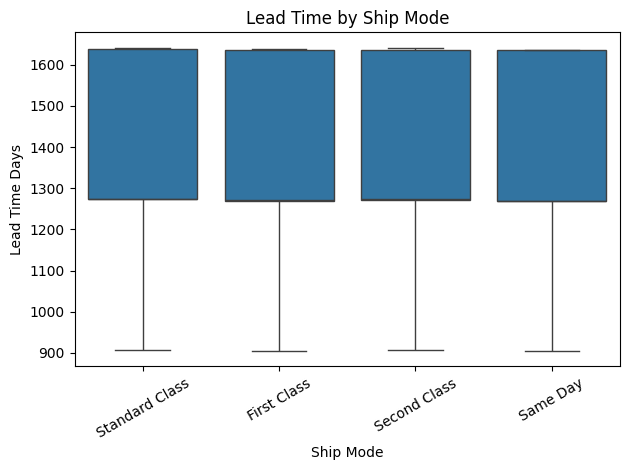

In [6]:
sns.boxplot(
    data=df,
    x="Ship Mode",
    y="Lead Time Days"
)

plt.title("Lead Time by Ship Mode")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

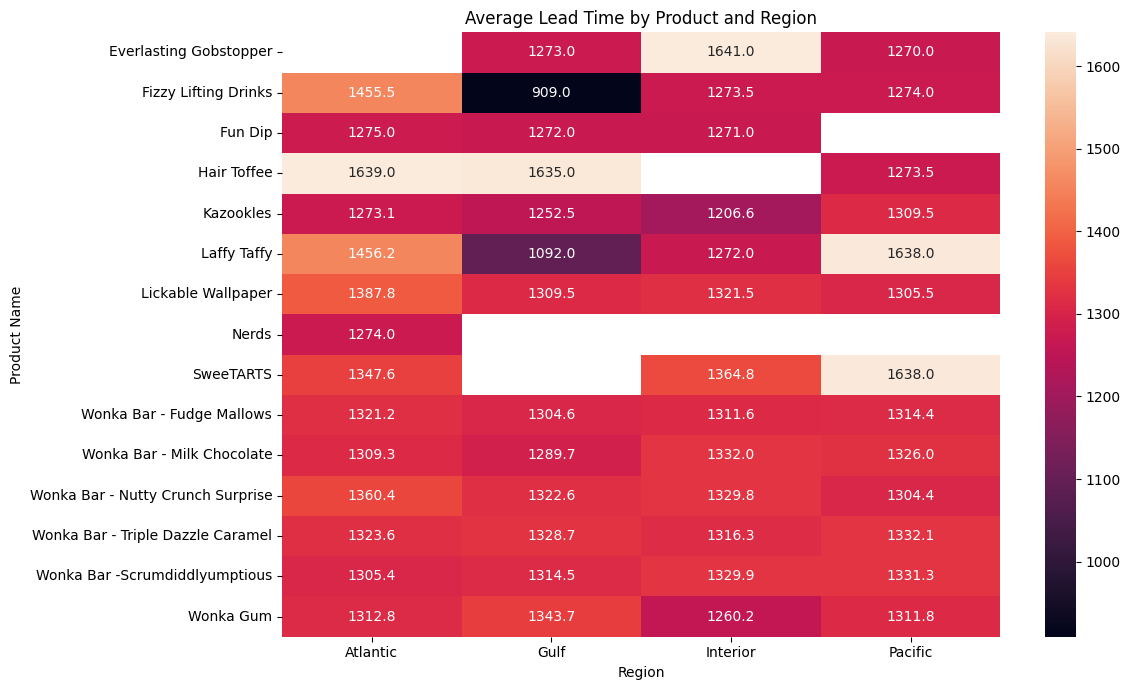

In [7]:
heatmap_data = df.pivot_table(
    index="Product Name",
    columns="Region",
    values="Lead Time Days",
    aggfunc="mean"
)

plt.figure(figsize=(12,7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f"
)

plt.title(
    "Average Lead Time by Product and Region"
)

plt.tight_layout()
plt.show()

In [8]:
factory_data = pd.DataFrame({
    "Factory": [
        "Lot's O' Nuts",
        "Wicked Choccy's",
        "Sugar Shack",
        "Secret Factory",
        "The Other Factory"
    ],

    "Latitude": [
        32.881893,
        32.076176,
        48.119140,
        41.446333,
        35.117500
    ],

    "Longitude": [
        -111.768036,
        -81.088371,
        -96.181150,
        -90.565487,
        -89.971107
    ]
})

factory_data

,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


In [9]:
product_factory = pd.DataFrame({
    "Product Name": [
        "Wonka Bar - Nutty Crunch Surprise",
        "Wonka Bar - Fudge Mallows",
        "Wonka Bar -Scrumdiddlyumptious",
        "Wonka Bar - Milk Chocolate",
        "Wonka Bar - Triple Dazzle Caramel",
        "Laffy Taffy",
        "SweeTARTS",
        "Nerds",
        "Fun Dip",
        "Fizzy Lifting Drinks",
        "Everlasting Gobstopper",
        "Hair Toffee",
        "Lickable Wallpaper",
        "Wonka Gum",
        "Kazookles"
    ],

    "Factory": [
        "Lot's O' Nuts",
        "Lot's O' Nuts",
        "Lot's O' Nuts",
        "Wicked Choccy's",
        "Wicked Choccy's",
        "Sugar Shack",
        "Sugar Shack",
        "Sugar Shack",
        "Sugar Shack",
        "Sugar Shack",
        "Secret Factory",
        "The Other Factory",
        "Secret Factory",
        "Secret Factory",
        "The Other Factory"
    ]
})

In [10]:
print(
    sorted(df["Product Name"].unique())
)

['Everlasting Gobstopper', 'Fizzy Lifting Drinks', 'Fun Dip', 'Hair Toffee', 'Kazookles', 'Laffy Taffy', 'Lickable Wallpaper', 'Nerds', 'SweeTARTS', 'Wonka Bar - Fudge Mallows', 'Wonka Bar - Milk Chocolate', 'Wonka Bar - Nutty Crunch Surprise', 'Wonka Bar - Triple Dazzle Caramel', 'Wonka Bar -Scrumdiddlyumptious', 'Wonka Gum']


In [11]:
print(
    sorted(product_factory["Product Name"].unique())
)

['Everlasting Gobstopper', 'Fizzy Lifting Drinks', 'Fun Dip', 'Hair Toffee', 'Kazookles', 'Laffy Taffy', 'Lickable Wallpaper', 'Nerds', 'SweeTARTS', 'Wonka Bar - Fudge Mallows', 'Wonka Bar - Milk Chocolate', 'Wonka Bar - Nutty Crunch Surprise', 'Wonka Bar - Triple Dazzle Caramel', 'Wonka Bar -Scrumdiddlyumptious', 'Wonka Gum']


In [12]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Calculated Gross Profit', 'Profit Difference', 'Order Date Raw', 'Ship Date Raw', 'Order Date Parsed', 'Ship Date Parsed', 'Lead Time Days', 'Profit Margin', 'Sales per Unit', 'Profit per Unit', 'Order Year', 'Order Month', 'Order Quarter', 'Order DayOfWeek']


In [13]:
print(
    [col for col in df.columns if "Factory" in col]
)

[]


In [14]:
factory_cols = [
    col for col in df.columns
    if col.startswith("Factory")
]

df = df.drop(columns=factory_cols)

print(
    [col for col in df.columns if "Factory" in col]
)

[]


In [15]:
print(product_factory.head())
print(product_factory.columns.tolist())

                        Product Name          Factory
0  Wonka Bar - Nutty Crunch Surprise    Lot's O' Nuts
1          Wonka Bar - Fudge Mallows    Lot's O' Nuts
2     Wonka Bar -Scrumdiddlyumptious    Lot's O' Nuts
3         Wonka Bar - Milk Chocolate  Wicked Choccy's
4  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's
['Product Name', 'Factory']


In [16]:
product_factory = product_factory[
    ["Product Name", "Factory"]
].copy()

In [17]:
df["Product Name"] = (
    df["Product Name"]
    .astype(str)
    .str.strip()
)

product_factory["Product Name"] = (
    product_factory["Product Name"]
    .astype(str)
    .str.strip()
)

In [18]:
unmatched_products = set(df["Product Name"].unique()) - set(
    product_factory["Product Name"].unique()
)

print("Unmatched products:")
print(unmatched_products)

print("Number of unmatched products:", len(unmatched_products))

Unmatched products:
set()
Number of unmatched products: 0


In [19]:
df = df.merge(
    product_factory,
    on="Product Name",
    how="left",
    validate="many_to_one"
)

In [20]:
print("Dataset shape:", df.shape)

print(
    "Missing Factory Assignments:",
    df["Factory"].isna().sum()
)

Dataset shape: (10194, 33)
Missing Factory Assignments: 0


In [21]:
display(
    df[
        ["Product Name", "Factory"]
    ].drop_duplicates().sort_values("Product Name")
)

,Product Name,Factory
4729,Everlasting Gobstopper,Secret Factory
191,Fizzy Lifting Drinks,Sugar Shack
5007,Fun Dip,Sugar Shack
4435,Hair Toffee,The Other Factory
26,Kazookles,The Other Factory
226,Laffy Taffy,Sugar Shack
136,Lickable Wallpaper,Secret Factory
1490,Nerds,Sugar Shack
973,SweeTARTS,Sugar Shack
13,Wonka Bar - Fudge Mallows,Lot's O' Nuts


In [25]:
df = pd.read_csv(
    r"/content/nassau_candy_cleaned.csv"
)